### ¿Qué es el Gradiente Descendente?

Es un algoritmo de optimización iterativo utilizado para encontrar el valor mínimo de una función (generalmente una función de costo o error). Su objetivo es ajustar los parámetros de un modelo paso a paso para minimizar el error entre las predicciones y los datos reales. Imagina que estás en la cima de una montaña a oscuras y quieres bajar al punto más bajo; el algoritmo "tantea" la pendiente y da un paso en la dirección donde el descenso es más pronunciado.

### Fórmula

La regla de actualización de los parámetros se define matemáticamente como:

$$ w(t+1) = w(t) - \alpha \cdot \nabla w(t) $$

### Explicación de los parámetros:

*   **$w(t)$:** Son los **parámetros** (pesos) del modelo en la iteración actual $t$.
*   **$w(t+1)$:** Son los **nuevos parámetros** actualizados para la siguiente iteración.
*   **$\alpha$ (Alpha):** Es la **Tasa de Aprendizaje (Learning Rate)**. Determina el tamaño del paso que damos en cada iteración.
    *   Si es muy **grande**, podemos saltarnos el mínimo.
    *   Si es muy **pequeño**, el algoritmo tardará mucho en converger.
*   **$\nabla w(t)$:** Es el **gradiente** (nabla) de la función de costo en el punto actual $w(t)$. Indica la dirección de mayor crecimiento, por lo que nos movemos en sentido opuesto.
*   **El signo menos ($-$)**: Es fundamental, ya que queremos ir en contra del gradiente (hacia abajo) para minimizar el error.

In [84]:
import numpy as np
import matplotlib.pyplot as plt

In [85]:
#--------funciones a encontrar el minimo----
def f(x):
    return x**2

def g(x):
    return x**4-4*x**2+x

#----------gradiente de la funciones----
def df(x):
    return 2*x
def dg(x):
    return 4*x**3 - 8*x + 1

valor inicial de x:  -7.979797979797979
valor de la derivada -15.959595959595958
valor de la derivada -6.383838383838384
valor de la derivada -2.553535353535354
valor de la derivada -1.0214141414141416
valor de la derivada -0.4085656565656567
valor de la derivada -0.1634262626262627
valor de la derivada -0.06537050505050508
valor de la derivada -0.026148202020202037
valor de la derivada -0.010459280808080815
valor de la derivada -0.004183712323232326
valor de la derivada -0.0016734849292929306
valor de la derivada final -0.0006693939717171723
valor de x que minimiza la función -0.00033469698585858617
numero de iteraciones 10


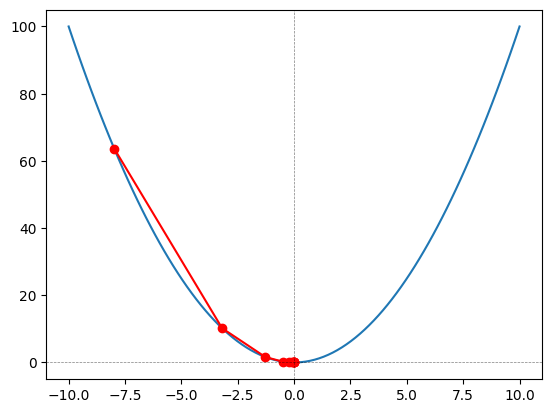

In [87]:
x = np.linspace(-10,10,100)
y = f(x)
alpha = 0.3 #---tasa de aprendizaje---
iteraciones = 100
historial_x = []
x_actual = x[10] #valor en donde inicia la búsqueda del mínimo
print(f"valor inicial de x:  {x_actual}")

for i in range(iteraciones):
    print("valor de la derivada",df(x_actual))
    historial_x.append(x_actual)
    x_actual = x_actual - alpha*df(x_actual)
    if (abs(df(x_actual))<=0.001):
      print("valor de la derivada final",df(x_actual))
      print("valor de x que minimiza la función",x_actual)
      break

print("numero de iteraciones", i)
#------graficar-----
plt.plot(x,y)
plt.plot(historial_x,f(np.array(historial_x)),'-ro')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
plt.show()

## Análisis de función no convexa (Múltiples Mínimos)

Analizaremos la función $g(x) = x^4 - 4x^2 + x$, que tiene una forma de "W" asimétrica, con un mínimo global (el más profundo) y un mínimo local (menos profundo).

### Caso 1: Inicio favorable (Convergencia al Global)
Si iniciamos el algoritmo en la parte izquierda ($x=-2.5$), el gradiente nos lleva naturalmente hacia "abajo" hasta encontrar el pozo más profundo (Mínimo Global).

1. Iniciando búsqueda desde x = -2.5
   Convergió en iteración 24
   Mínimo encontrado en x=-1.4730, f(x)=-5.4442 (GLOBAL)


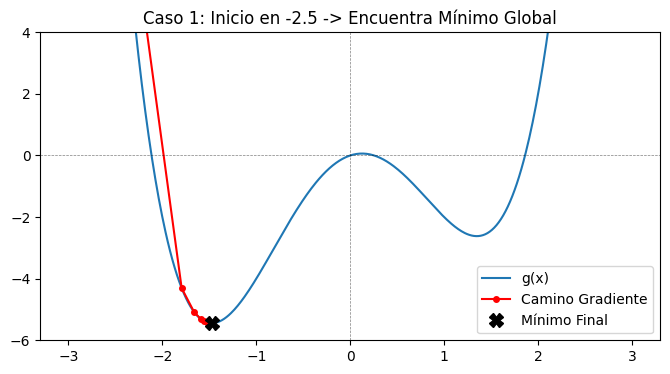

In [88]:
x = np.linspace(-3,3,500)
y = g(x)
alpha = 0.017 
iteraciones = 100

# --- CASO 1: Arrancando desde la izquierda ---
x_inicio = -2.5

historial_x = []
x_actual = x_inicio
print(f"1. Iniciando búsqueda desde x = {x_actual}")  

for i in range(iteraciones):
    historial_x.append(x_actual)
    derivada = dg(x_actual)
    x_actual = x_actual - alpha*derivada
    if (abs(derivada)<=0.001):
      print(f"   Convergió en iteración {i}")
      print(f"   Mínimo encontrado en x={x_actual:.4f}, f(x)={g(x_actual):.4f} (GLOBAL)")
      break

#------graficar-----
plt.figure(figsize=(8,4))
plt.plot(x,y, label='g(x)')
plt.plot(historial_x, g(np.array(historial_x)), '-ro', label='Camino Gradiente', markersize=4)
plt.plot(x_actual, g(x_actual), 'X', color='black', markersize=10, label='Mínimo Final')
plt.title(f"Caso 1: Inicio en {x_inicio} -> Encuentra Mínimo Global")
plt.ylim(-6,4)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Caso 2: El problema de los Mínimos Locales
Si iniciamos el algoritmo por la derecha ($x=2.5$), la pendiente solo "ve" el pozo más cercano. El algoritmo baja hasta el fondo de ese valle y se detiene, creyendo que ha terminado. No tiene forma de "ver" que existe un valle más profundo más lejos. **Se queda atrapado en un Mínimo Local.**

2. Iniciando búsqueda desde x = 2.5
   Convergió en iteración 32
   Mínimo encontrado en x=1.3470, f(x)=-2.6186 (LOCAL, NO GLOBAL)


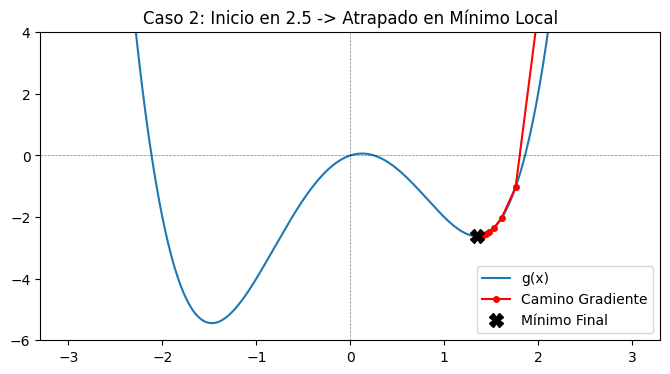

In [89]:
# --- CASO 2: Arrancando desde la derecha ---
x_inicio = 2.5

historial_x = []
x_actual = x_inicio
print(f"2. Iniciando búsqueda desde x = {x_actual}")  

for i in range(iteraciones):
    historial_x.append(x_actual)
    derivada = dg(x_actual)
    x_actual = x_actual - alpha*derivada
    if (abs(derivada)<=0.001):
      print(f"   Convergió en iteración {i}")
      print(f"   Mínimo encontrado en x={x_actual:.4f}, f(x)={g(x_actual):.4f} (LOCAL, NO GLOBAL)")
      break

#------graficar-----
plt.figure(figsize=(8,4))
plt.plot(x,y, label='g(x)')
# Nota: Uso color rojo ('-ro') para mantener consistencia con lo solicitado
plt.plot(historial_x, g(np.array(historial_x)), '-ro', label='Camino Gradiente', markersize=4) 
plt.plot(x_actual, g(x_actual), 'X', color='black', markersize=10, label='Mínimo Final')
plt.title(f"Caso 2: Inicio en {x_inicio} -> Atrapado en Mínimo Local")
plt.ylim(-6,4)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Solución: Múltiples Arranques Aleatorios (Random Restarts)

Como el Gradiente Descendente es un algoritmo "ciego" (local), una estrategia robusta para intentar encontrar el mínimo global es:
1. Definir un número de intentos ($N$).
2. En cada intento, elegir un **punto de inicio aleatorio** dentro del rango.
3. Ejecutar el descenso y guardar el resultado (valor final de $y$).
4. Al finalizar todos los intentos, **comparar** y elegir la mejor solución (el $y$ más bajo).

A continuación, ejecutamos 5 intentos automáticos. Verás en las líneas de colores cómo explora diferentes zonas.

3. Iniciando Múltiples Intentos Aleatorios:
   Intento 1: Inicio=1.33 -> Fin=-2.6186
   Intento 2: Inicio=0.60 -> Fin=-2.6186
   Intento 3: Inicio=-1.68 -> Fin=-5.4442
   Intento 4: Inicio=-2.18 -> Fin=-5.4442
   Intento 5: Inicio=1.95 -> Fin=-2.6186

--- CONCLUSIÓN ---
El Mínimo Global detectado es f(x)=-5.4442 en x=-1.4730


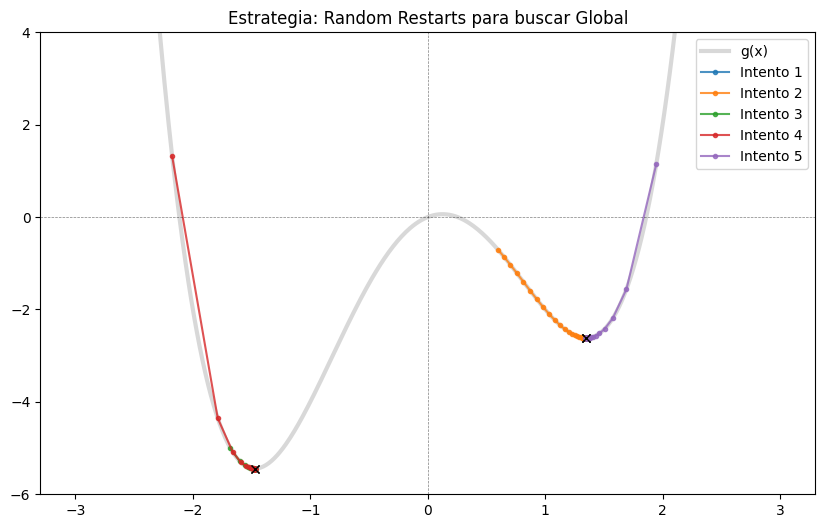

In [90]:
# --- SOLUCIÓN: Intentos Aleatorios ---
num_intentos = 5
mejores_resultados = [] # Guardaremos tuplas (x_final, y_final)

plt.figure(figsize=(10,6))
plt.plot(x,y, color='gray', alpha=0.3, label='g(x)', linewidth=3)

print("3. Iniciando Múltiples Intentos Aleatorios:")

for intento in range(num_intentos):
    # Generar punto de inicio aleatorio entre -2.5 y 2.5
    x_inicio = np.random.uniform(-2.5, 2.5)
    
    x_actual = x_inicio
    x_camino = [x_actual]
    
    # Ejecutar Gradiente Descendente
    for i in range(iteraciones):
        derivada = dg(x_actual)
        x_actual = x_actual - alpha*derivada
        x_camino.append(x_actual)
        if (abs(derivada)<=0.001):
            break
    
    # Evaluar resultado
    y_final = g(x_actual)
    mejores_resultados.append((x_actual, y_final))
    
    print(f"   Intento {intento+1}: Inicio={x_inicio:.2f} -> Fin={y_final:.4f}")
    
    # Graficar este intento
    plt.plot(x_camino, g(np.array(x_camino)), '.-', label=f'Intento {intento+1}', alpha=0.8)
    plt.plot(x_actual, y_final, 'x', color='black')

# Encontrar el mejor resultado de todos
mejor_x, mejor_y = min(mejores_resultados, key=lambda t: t[1])

print(f"\n--- CONCLUSIÓN ---")
print(f"El Mínimo Global detectado es f(x)={mejor_y:.4f} en x={mejor_x:.4f}")

plt.title("Estrategia: Random Restarts para buscar Global")
plt.ylim(-6,4)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
plt.legend()
plt.show()